# Notebook 10 — m=1 Population Distributions

Distribution analysis for the 31 manually verified m=1 simple cells.
Loaded directly from `m1_neuron_dataset.pkl` — no re-fitting needed.

**Confidence parameters overlaid on all distributions:**
- **R²** — fit quality tier (≥0.5 reliable, 0.4–0.5 marginal, <0.4 weak)
- **Orientation sharpness** — max/mean |r| across 18-step angle grid
  (≥2.5 = clear peak, 1.5–2.5 = weak, <1.5 = flat landscape)


In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import pearsonr, circstd
from scipy.ndimage import gaussian_filter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

DATASET_PATH = Path(
    '~/dev/neuroscience/v1-dimensionality-study/outputs/rf_params'
    '/order_full_v2/rf_gallery/m1_neuron_dataset.pkl'
).expanduser()

with open(DATASET_PATH, 'rb') as f:
    dataset = pickle.load(f)

# Flat dataframe of scalar fields for easy plotting
SCALAR_KEYS = [
    'name', 'name_rank', 'cell_id', 'kappa', 'sigma_deg',
    'kappa_dir', 'sigma_phi_deg', 'sigma_orth_deg',
    'sigma_x_deg', 'sigma_y_deg', 'x0_deg', 'y0_deg',
    'theta_envelope', 'phi_deg', 'phi_confidence', 'edge_orientation',
    'r_squared', 'rmse', 'aic',
    'delta_r2_vs_m0', 'r2_m0', 'r2_m1', 'r2_m2',
    'low_kappa', 'low_r2', 'orientation_sharpness',
    'cre_line', 'imaging_depth_um', 'cortex_x_um', 'cortex_y_um',
]
df = pd.DataFrame([{k: r.get(k) for k in SCALAR_KEYS} for r in dataset])

# Confidence tier labels
df['r2_tier'] = pd.cut(df['r_squared'],
                       bins=[-np.inf, 0.4, 0.5, np.inf],
                       labels=['R²<0.40  (weak)', '0.40≤R²<0.50  (marginal)', 'R²≥0.50  (reliable)'])

df['sharp_tier'] = pd.cut(df['orientation_sharpness'],
                          bins=[-np.inf, 1.5, 2.5, np.inf],
                          labels=['<1.5  (flat)', '1.5–2.5  (weak)', '≥2.5  (reliable)'])

R2_COLOURS   = {'R²<0.40  (weak)': '#e74c3c',
                '0.40≤R²<0.50  (marginal)': '#f39c12',
                'R²≥0.50  (reliable)': '#1a7a4a'}
SHARP_COLOURS = {'<1.5  (flat)': '#bbdefb',
                 '1.5–2.5  (weak)': '#42a5f5',
                 '≥2.5  (reliable)': '#1565c0'}

# Direction-aware elongation kappa_dir = sigma_orth/sigma_phi (alongside max/min kappa).
# Exact from the rebuilt dataset; reconstructed from phi vs theta_envelope if the
# pickle predates the fix (the fit's differentiation axis is a principal axis, so
# kappa_dir is 1/kappa when differentiation is along the major axis, else kappa).
if 'kappa_dir' not in df.columns or df['kappa_dir'].isna().all():
    def _afold(a, b):
        d = abs(a - b) % 180
        return min(d, 180 - d)
    _diff = df.apply(lambda r: _afold(r['phi_deg'], r['theta_envelope']), axis=1)
    df['kappa_dir'] = np.where(_diff < 45, 1.0 / df['kappa'], df['kappa'])

n = len(df)
print(f'Loaded {n} neurons')
print(df[['name','kappa','r_squared','orientation_sharpness','sharp_tier']].to_string(index=False))


Loaded 31 neurons
     name    kappa  r_squared  orientation_sharpness      sharp_tier
Georgette 1.227133   0.495243               1.592966 1.5–2.5  (weak)
    Steve 1.329166   0.452365               1.630710 1.5–2.5  (weak)
Cassandra 1.494872   0.554440               1.677694 1.5–2.5  (weak)
Garibaldi 1.069809   0.348701               1.570197 1.5–2.5  (weak)
 Gertrude 1.111595   0.482495               1.572868 1.5–2.5  (weak)
   Vasily 1.245663   0.506590               1.603551 1.5–2.5  (weak)
Hildegard 1.038205   0.552859               1.564740 1.5–2.5  (weak)
    Bobby 1.066704   0.580120               1.570388 1.5–2.5  (weak)
Valentina 1.204784   0.498278               1.595758 1.5–2.5  (weak)
     Ting 1.647091   0.723403               1.760755 1.5–2.5  (weak)
 Mathilde 1.677704   0.480662               1.726665 1.5–2.5  (weak)
  Crispin 1.943461   0.385080               1.933247 1.5–2.5  (weak)
 Leontine 1.479367   0.550962               1.695705 1.5–2.5  (weak)
 Reginald 1.3034

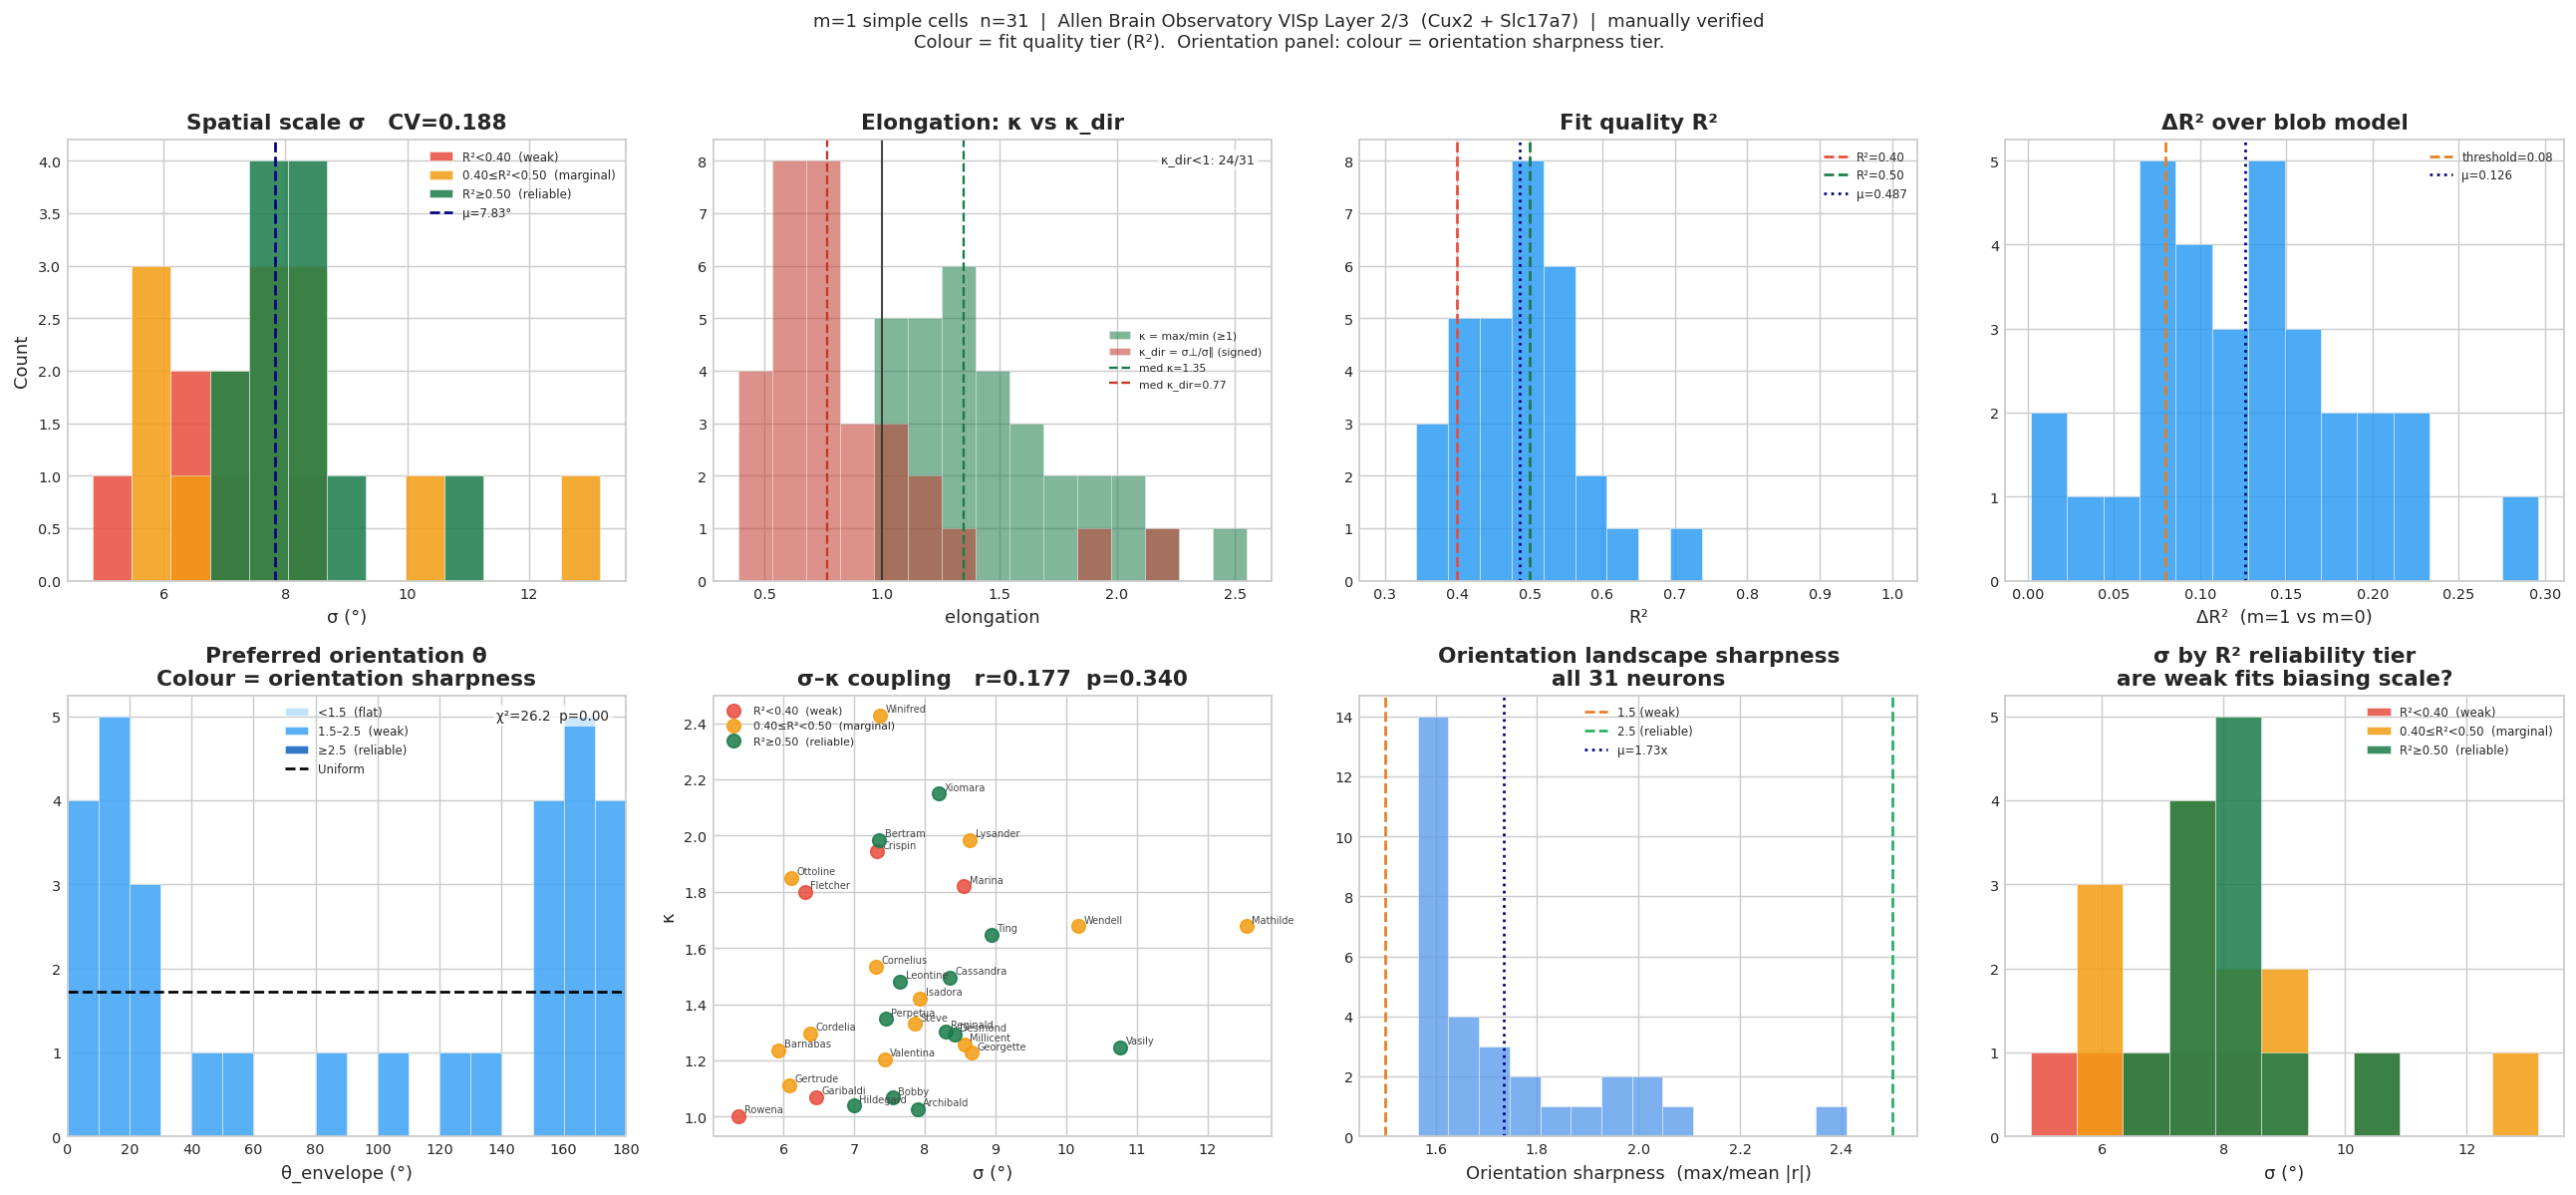

Saved PNG + PDF


In [2]:
# ---------------------------------------------------------------------------
# 2×4 population overview — matching nb06 structure, with confidence layers
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    f'm=1 simple cells  n={n}  |  Allen Brain Observatory VISp Layer 2/3  '
    f'(Cux2 + Slc17a7)  |  manually verified\n'
    f'Colour = fit quality tier (R²).  '
    f'Orientation panel: colour = orientation sharpness tier.',
    fontsize=10, y=1.02
)

BW = dict(edgecolor='white', linewidth=0.3)

# ── (0,0) σ distribution with R² tiers ───────────────────────────────────
ax = axes[0,0]
bins_s = np.linspace(df['sigma_deg'].min()*0.9, df['sigma_deg'].max()*1.05, 14)
for tier, col in R2_COLOURS.items():
    sub = df[df['r2_tier']==tier]['sigma_deg'].dropna()
    ax.hist(sub, bins=bins_s, color=col, alpha=0.85, label=tier, **BW)
ax.axvline(df['sigma_deg'].mean(), color='navy', ls='--', lw=1.5,
           label=f'μ={df["sigma_deg"].mean():.2f}°')
cv = df['sigma_deg'].std() / df['sigma_deg'].mean()
ax.set_xlabel('σ (°)'); ax.set_ylabel('Count')
ax.set_title(f'Spatial scale σ   CV={cv:.3f}', fontweight='bold')
ax.legend(fontsize=6.5, loc='upper right')

# (0,1) Elongation: kappa (max/min, >=1) vs kappa_dir (direction-aware, signed)
ax = axes[0,1]
kd = df['kappa_dir'].dropna()
lo = min(0.95, kd.min()*0.95) if len(kd) else 0.95
hi = max(df['kappa'].max(), kd.max() if len(kd) else 1.0) * 1.05
bins_k = np.linspace(lo, hi, 16)
ax.hist(df['kappa'].dropna(), bins=bins_k, color='#1a7a4a', alpha=0.55,
        label='κ = max/min (≥1)', **BW)
ax.hist(kd, bins=bins_k, color='#c0392b', alpha=0.55,
        label='κ_dir = σ⊥/σ∥ (signed)', **BW)
ax.axvline(1.0, color='#333', ls='-', lw=1.0)
ax.axvline(df['kappa'].median(), color='#1a7a4a', ls='--', lw=1.3,
           label=f'med κ={df["kappa"].median():.2f}')
ax.axvline(kd.median(), color='#c0392b', ls='--', lw=1.3,
           label=f'med κ_dir={kd.median():.2f}')
n_wen = int((df['kappa_dir'] < 1).sum())
ax.set_xlabel('elongation'); ax.set_title('Elongation: κ vs κ_dir', fontweight='bold')
ax.legend(fontsize=6)
ax.text(0.97, 0.97, f'κ_dir<1: {n_wen}/{n}', transform=ax.transAxes,
        ha='right', va='top', fontsize=7,
        bbox=dict(facecolor='white', alpha=0.7, pad=2, edgecolor='none'))

# ── (0,2) R² distribution ─────────────────────────────────────────────────
ax = axes[0,2]
ax.hist(df['r_squared'], bins=16, range=(0.3, 1.0), color='#2196F3', alpha=0.8, **BW)
ax.axvline(0.4,  color='#e74c3c',  ls='--', lw=1.5, label='R²=0.40')
ax.axvline(0.5,  color='#1a7a4a',  ls='--', lw=1.5, label='R²=0.50')
ax.axvline(df['r_squared'].mean(), color='navy', ls=':',  lw=1.5,
           label=f'μ={df["r_squared"].mean():.3f}')
ax.set_xlabel('R²'); ax.set_title('Fit quality R²', fontweight='bold')
ax.legend(fontsize=6.5)

# ── (0,3) ΔR² vs m=0 distribution ────────────────────────────────────────
ax = axes[0,3]
dr2 = df['delta_r2_vs_m0'].dropna()
ax.hist(dr2, bins=14, color='#2196F3', alpha=0.8, **BW)
ax.axvline(0.08, color='#e67e22', ls='--', lw=1.5, label='threshold=0.08')
ax.axvline(dr2.mean(), color='navy', ls=':', lw=1.5,
           label=f'μ={dr2.mean():.3f}')
ax.set_xlabel('ΔR²  (m=1 vs m=0)')
ax.set_title('ΔR² over blob model', fontweight='bold')
ax.legend(fontsize=6.5)

# ── (1,0) θ orientation — coloured by sharpness tier ─────────────────────
from scipy.stats import chisquare
ax = axes[1,0]
obs, _ = np.histogram(df['theta_envelope'].dropna(), bins=9, range=(0, 180))
chi2, p_chi = chisquare(obs)

bins_t = np.linspace(0, 180, 19)
for tier, col in SHARP_COLOURS.items():
    sub = df[df['sharp_tier']==tier]['theta_envelope'].dropna()
    ax.hist(sub, bins=bins_t, color=col, alpha=0.88, label=tier, **BW)
ax.axhline(n/18, color='black', ls='--', lw=1.5, label='Uniform')
ax.set_xlabel('θ_envelope (°)')
ax.set_xlim(0, 180)
ax.set_title('Preferred orientation θ\nColour = orientation sharpness', fontweight='bold')
ax.legend(fontsize=6.5)
ax.text(0.97, 0.97, f'χ²={chi2:.1f}  p={p_chi:.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
        bbox=dict(facecolor='white', alpha=0.7, pad=2, edgecolor='none'))

# ── (1,1) σ–κ scatter coloured by R² ─────────────────────────────────────
ax = axes[1,1]
r2_cmap = {'R²<0.40  (weak)': '#e74c3c',
           '0.40≤R²<0.50  (marginal)': '#f39c12',
           'R²≥0.50  (reliable)': '#1a7a4a'}
for tier, col in r2_cmap.items():
    sub = df[df['r2_tier']==tier]
    ax.scatter(sub['sigma_deg'], sub['kappa'], c=col, s=55,
               alpha=0.85, zorder=3, label=tier)
    for _, row in sub.iterrows():
        ax.annotate(row['name'], (row['sigma_deg'], row['kappa']),
                    textcoords='offset points', xytext=(3,2),
                    fontsize=5.5, color='#444')
valid = df[['sigma_deg','kappa']].dropna()
if len(valid) > 2:
    r, p = pearsonr(valid['sigma_deg'], valid['kappa'])
    ax.set_title(f'σ–κ coupling   r={r:.3f}  p={p:.3f}', fontweight='bold')
ax.set_xlabel('σ (°)'); ax.set_ylabel('κ')
ax.legend(fontsize=6, loc='upper left')

# ── (1,2) Orientation sharpness distribution ──────────────────────────────
ax = axes[1,2]
ax.hist(df['orientation_sharpness'], bins=14, color='#5d9cec', alpha=0.8, **BW)
ax.axvline(1.5, color='#e67e22', ls='--', lw=1.5, label='1.5 (weak)')
ax.axvline(2.5, color='#27ae60', ls='--', lw=1.5, label='2.5 (reliable)')
ax.axvline(df['orientation_sharpness'].mean(), color='navy', ls=':', lw=1.5,
           label=f'μ={df["orientation_sharpness"].mean():.2f}x')
ax.set_xlabel('Orientation sharpness  (max/mean |r|)')
ax.set_title('Orientation landscape sharpness\nall 31 neurons', fontweight='bold')
ax.legend(fontsize=6.5)

# ── (1,3) σ split by R² tier (reliability check) ─────────────────────────
ax = axes[1,3]
bins_sr = np.linspace(df['sigma_deg'].min()*0.9, df['sigma_deg'].max()*1.05, 12)
for tier, col in R2_COLOURS.items():
    sub = df[df['r2_tier']==tier]['sigma_deg'].dropna()
    ax.hist(sub, bins=bins_sr, color=col, alpha=0.85, label=tier, **BW)
ax.set_xlabel('σ (°)')
ax.set_title('σ by R² reliability tier\nare weak fits biasing scale?', fontweight='bold')
ax.legend(fontsize=6.5)

for ax in axes.flat:
    ax.tick_params(labelsize=8)

plt.tight_layout()

out_dir = Path('~/dev/neuroscience/v1-dimensionality-study/outputs/rf_params'
               '/order_full_v2/rf_gallery').expanduser()
plt.savefig(out_dir / 'fig_m1_population_overview.png', dpi=160, bbox_inches='tight')
plt.savefig(out_dir / 'fig_m1_population_overview.pdf', bbox_inches='tight')
plt.show()
print('Saved PNG + PDF')


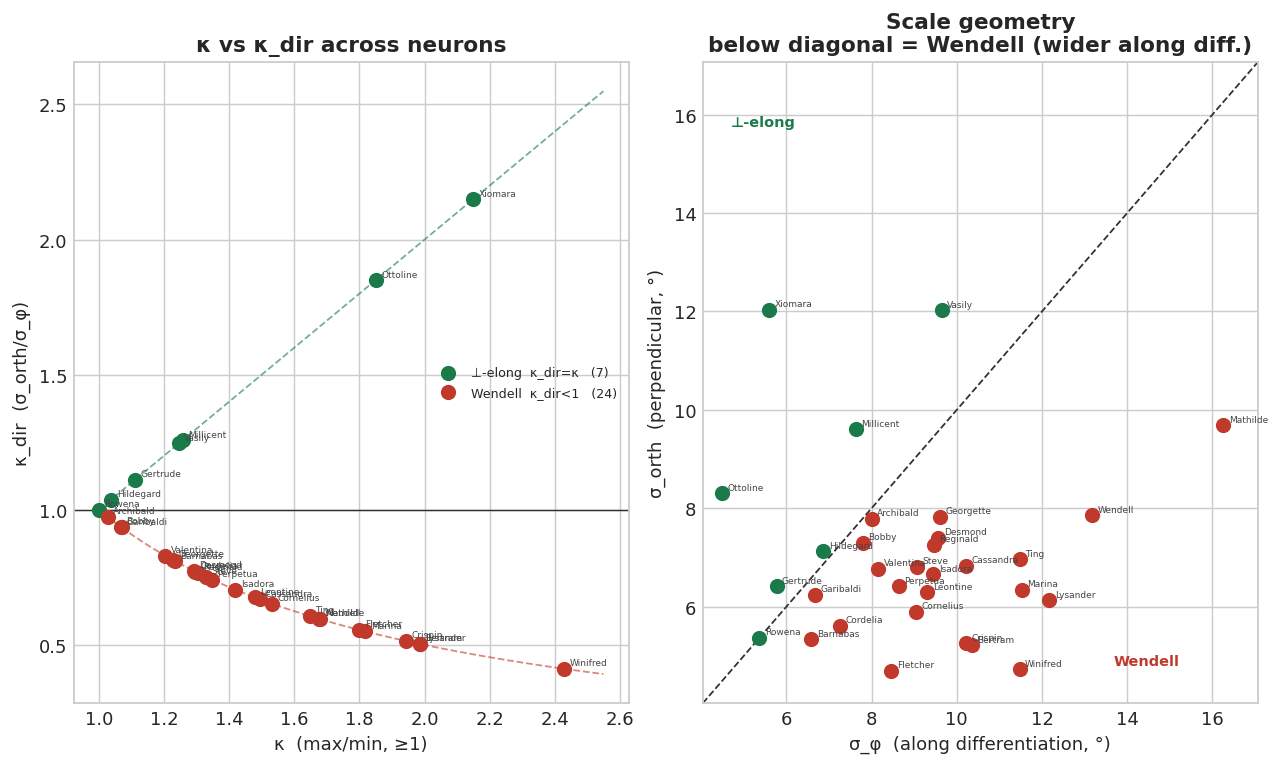


Wendell tail (κ_dir < 1):  24/31
     name  kappa  kappa_dir  sig_phi  sig_orth  theta_envelope  phi_deg  r_squared
 Winifred   2.43       0.41    11.48      4.73            0.00   146.85       0.40
 Lysander   1.99       0.50    12.17      6.13          160.69     9.23       0.46
  Bertram   1.99       0.50    10.36      5.22          179.02    73.18       0.53
  Crispin   1.94       0.51    10.21      5.25          155.87   145.95       0.39
   Marina   1.82       0.55    11.53      6.34            1.57   149.36       0.39
 Fletcher   1.80       0.56     8.46      4.70           25.84     9.30       0.39
 Mathilde   1.68       0.60    16.25      9.69           15.23    11.59       0.48
  Wendell   1.68       0.60    13.18      7.86          163.40   138.22       0.44
     Ting   1.65       0.61    11.47      6.97          160.54   154.55       0.72
Cornelius   1.53       0.65     9.05      5.90          156.37   163.33       0.46
Cassandra   1.49       0.67    10.21      6.83       

NameError: name 'mism' is not defined

In [3]:
# ===========================================================================
# κ vs κ_dir diagnostics — comparison across neurons + scale geometry
# ===========================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
wen = df['kappa_dir'] < 1.0

if {'sigma_phi_deg', 'sigma_orth_deg'}.issubset(df.columns) and df['sigma_phi_deg'].notna().any():
    sig_phi, sig_orth = df['sigma_phi_deg'], df['sigma_orth_deg']
else:
    sig_phi  = pd.Series(np.where(wen, df['sigma_x_deg'], df['sigma_y_deg']), index=df.index)
    sig_orth = pd.Series(np.where(wen, df['sigma_y_deg'], df['sigma_x_deg']), index=df.index)

GREEN, RED, GREY, ORANGE = '#1a7a4a', '#c0392b', '#888', '#e67e22'

# (0) κ vs κ_dir — every point lands on κ_dir=κ or κ_dir=1/κ
a = ax[0]
a.scatter(df.loc[~wen,'kappa'], df.loc[~wen,'kappa_dir'], c=GREEN, s=55, zorder=3, label=f'⊥-elong  κ_dir=κ   ({int((~wen).sum())})')
a.scatter(df.loc[wen,'kappa'],  df.loc[wen,'kappa_dir'],  c=RED,   s=55, zorder=3, label=f'Wendell  κ_dir<1   ({int(wen.sum())})')
kk = np.linspace(1.0, df['kappa'].max()*1.05, 100)
a.plot(kk, kk, '--', color=GREEN, lw=1, alpha=0.6); a.plot(kk, 1.0/kk, '--', color=RED, lw=1, alpha=0.6)
a.axhline(1.0, color='#333', lw=0.8)
for _, r in df.iterrows():
    a.annotate(r['name'], (r['kappa'], r['kappa_dir']), textcoords='offset points', xytext=(3,2), fontsize=5, color='#444')
a.set_xlabel('κ  (max/min, ≥1)'); a.set_ylabel('κ_dir  (σ_orth/σ_φ)')
a.set_title('κ vs κ_dir across neurons', fontweight='bold'); a.legend(fontsize=7, loc='center right')

# (1) σ_φ vs σ_orth — geometry behind the split
a = ax[1]
a.scatter(sig_phi[~wen], sig_orth[~wen], c=GREEN, s=55, zorder=3)
a.scatter(sig_phi[wen],  sig_orth[wen],  c=RED,   s=55, zorder=3)
lim = [min(sig_phi.min(), sig_orth.min())*0.9, max(sig_phi.max(), sig_orth.max())*1.05]
a.plot(lim, lim, '--', color='#333', lw=1)
for _, r in df.iterrows():
    a.annotate(r['name'], (sig_phi[r.name], sig_orth[r.name]), textcoords='offset points', xytext=(3,2), fontsize=5, color='#444')
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel('σ_φ  (along differentiation, °)'); a.set_ylabel('σ_orth  (perpendicular, °)')
a.set_title('Scale geometry\nbelow diagonal = Wendell (wider along diff.)', fontweight='bold')
a.text(0.05,0.90,'⊥-elong', transform=a.transAxes, fontsize=8, color=GREEN, fontweight='bold')
a.text(0.74,0.06,'Wendell', transform=a.transAxes, fontsize=8, color=RED, fontweight='bold')

plt.tight_layout(); 

out_dir = Path('~/dev/neuroscience/v1-dimensionality-study/outputs/rf_params'
               '/order_full_v2/rf_gallery').expanduser()
plt.savefig(out_dir / 'fig_m1_k_vs_k_dir.png', dpi=160, bbox_inches='tight')
plt.savefig(out_dir / 'fig_m1_k_vs_k_dir.pdf', bbox_inches='tight')

plt.show()

# Wendell tail table
wt = df[df['kappa_dir'] < 1].copy()
wt['sig_phi'], wt['sig_orth'] = sig_phi[wt.index], sig_orth[wt.index]
wt = wt.sort_values('kappa_dir')
print(f'\nWendell tail (κ_dir < 1):  {len(wt)}/{len(df)}')
print(wt[['name','kappa','kappa_dir','sig_phi','sig_orth','theta_envelope','phi_deg','r_squared']].round(2).to_string(index=False))
if mism.any():
    print(f'\nφ-reconstruction misclassifies {int(mism.sum())} neuron(s): ' + ', '.join(df.loc[mism,'name']))
    print('  → trust the exact κ_dir (fit σ_φ/σ_orth), not the φ-rule, for these.')

In [ ]:
# ===========================================================================
# Envelope-shape control: is κ_dir<1 real envelope elongation, or lobe spacing?
# ===========================================================================
# κ_dir comes from the m=1 fit, where σ_φ = lobe HALF-SEPARATION (lobes peak at
# u=±σ_u).  So κ_dir<1 could mean "wide envelope along differentiation" OR just
# "lobes well separated".  This cell measures the envelope shape a DIFFERENT
# way — the second-moment ellipse of each SINGLE lobe, about its own centroid,
# which contains no separation information at all:
#     κ_lobe = sqrt(var_perp / var_along)   (perpendicular vs along differentiation)
# If κ_lobe ≈ κ_dir → κ_dir reflects genuine envelope anisotropy.
# If κ_lobe ≳ 1 while κ_dir < 1 → the κ_dir<1 signal is lobe SPACING, not envelope.

def _wcov(mass, X, Y):
    W = mass.sum()
    if W < 1e-9:
        return None, None
    mx, my = (mass*X).sum()/W, (mass*Y).sum()/W
    dx, dy = X - mx, Y - my
    cov = np.array([[(mass*dx*dx).sum()/W, (mass*dx*dy).sum()/W],
                    [(mass*dx*dy).sum()/W, (mass*dy*dy).sum()/W]])
    return np.array([mx, my]), cov

def lobe_envelope(rf, thresh_frac=0.25):
    """Single-lobe envelope elongation perpendicular/along the differentiation
    axis, free of lobe-separation.  Returns (kappa_lobe, sep_px, phi_axis_deg)."""
    H, W = rf.shape
    Y, X = np.mgrid[0:H, 0:W].astype(float)
    on, off = np.clip(rf, 0, None), np.clip(-rf, 0, None)
    on  = np.where(on  > thresh_frac*on.max(),  on,  0.0)
    off = np.where(off > thresh_frac*off.max(), off, 0.0)
    c_on,  cov_on  = _wcov(on,  X, Y)
    c_off, cov_off = _wcov(off, X, Y)
    if c_on is None or c_off is None:
        return np.nan, np.nan, np.nan
    d = c_on - c_off
    sep = float(np.hypot(*d))
    if sep < 1e-6:
        return np.nan, np.nan, np.nan
    e_phi  = d / sep                       # differentiation axis (data-derived)
    e_perp = np.array([-e_phi[1], e_phi[0]])
    m_on, m_off = on.sum(), off.sum()
    va = (m_on*(e_phi @cov_on @e_phi) + m_off*(e_phi @cov_off @e_phi)) / (m_on+m_off)
    vp = (m_on*(e_perp@cov_on @e_perp)+ m_off*(e_perp@cov_off@e_perp)) / (m_on+m_off)
    kappa_lobe = float(np.sqrt(vp/va)) if va > 1e-9 else np.nan
    return kappa_lobe, sep, float(np.rad2deg(np.arctan2(e_phi[1], e_phi[0])) % 180)

# ── compute per neuron from the smoothed RF in the pickle records ──────────
rows = []
for r in dataset:
    kl, sep, ax = lobe_envelope(np.asarray(r['rf_smooth'], float))
    rows.append({'name': r['name'], 'kappa_lobe': kl, 'sep_px': sep,
                 'sigma_phi_px': r['sigma_phi_deg']/r['pixel_size_deg']})
mom = pd.DataFrame(rows).set_index('name')
dd = df.set_index('name').join(mom)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
wen = dd['kappa_dir'] < 1
GREEN, RED = '#1a7a4a', '#c0392b'

# (0) κ_dir (fit) vs κ_lobe (single-lobe, separation-free)
a = ax[0]
a.scatter(dd.loc[~wen,'kappa_dir'], dd.loc[~wen,'kappa_lobe'], c=GREEN, s=55, zorder=3, label='κ_dir≥1')
a.scatter(dd.loc[wen,'kappa_dir'],  dd.loc[wen,'kappa_lobe'],  c=RED,   s=55, zorder=3, label='κ_dir<1 (fit-Wendell)')
lim = [0.3, max(dd['kappa_dir'].max(), dd['kappa_lobe'].max())*1.05]
a.plot(lim, lim, '--', color='#333', lw=1, label='κ_dir = κ_lobe')
a.axhline(1, color='#888', lw=0.7); a.axvline(1, color='#888', lw=0.7)
for nm, r in dd.iterrows():
    a.annotate(nm, (r['kappa_dir'], r['kappa_lobe']), textcoords='offset points', xytext=(3,2), fontsize=5, color='#444')
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel('κ_dir   (from m=1 fit; σ_φ = lobe half-separation)')
a.set_ylabel('κ_lobe  (single-lobe envelope, separation-free)')
a.set_title('Does κ_dir<1 survive without the separation term?', fontweight='bold')
a.legend(fontsize=7)

# (1) σ_φ (fit) vs lobe half-separation — is σ_φ just encoding spacing?
a = ax[1]
a.scatter(dd['sep_px']/2, dd['sigma_phi_px'], c=np.where(wen, RED, GREEN), s=55, zorder=3)
lim2 = [0, max((dd['sep_px']/2).max(), dd['sigma_phi_px'].max())*1.05]
a.plot(lim2, lim2, '--', color='#333', lw=1, label='σ_φ = D/2')
a.set_xlim(lim2); a.set_ylim(lim2)
a.set_xlabel('lobe half-separation  D/2  (px, from centroids)')
a.set_ylabel('σ_φ  (px, from fit)')
a.set_title('Is σ_φ just the lobe spacing?', fontweight='bold'); a.legend(fontsize=7)

# (2) histograms: fit-Wendell vs envelope-Wendell
a = ax[2]
bins = np.linspace(0.3, max(dd['kappa_dir'].max(), dd['kappa_lobe'].max())*1.05, 16)
a.hist(dd['kappa_dir'].dropna(),  bins=bins, color=RED,   alpha=0.5, label='κ_dir (fit)')
a.hist(dd['kappa_lobe'].dropna(), bins=bins, color='#3b6ea5', alpha=0.5, label='κ_lobe (envelope)')
a.axvline(1, color='#333', ls='--', lw=1.3)
a.set_xlabel('elongation'); a.set_ylabel('neurons')
a.set_title('Distribution shift: spacing vs envelope', fontweight='bold'); a.legend(fontsize=7)
plt.tight_layout(); 
out_dir = Path('~/dev/neuroscience/v1-dimensionality-study/outputs/rf_params'
               '/order_full_v2/rf_gallery').expanduser()
plt.savefig(out_dir / 'fig_m1_k_vs_lobe_spacing.png', dpi=160, bbox_inches='tight')
plt.savefig(out_dir / 'fig_m1_k_vs_lobe_spacing.pdf', bbox_inches='tight')
plt.show()

n_fit_wen  = int((dd['kappa_dir']  < 1).sum())
n_env_wen  = int((dd['kappa_lobe'] < 1).sum())
sep_ratio  = (dd['sigma_phi_px'] / (dd['sep_px']/2)).median()
print(f'fit-Wendell   (κ_dir < 1):  {n_fit_wen}/{len(dd)}')
print(f'envelope-Wendell (κ_lobe<1): {n_env_wen}/{len(dd)}')
print(f'median σ_φ / (D/2):          {sep_ratio:.2f}   (≈1 ⇒ σ_φ is essentially the lobe half-separation)')
print(f'median κ_lobe:               {dd["kappa_lobe"].median():.2f}   vs median κ_dir {dd["kappa_dir"].median():.2f}')
if n_env_wen < n_fit_wen:
    print(f'\n⇒ {n_fit_wen - n_env_wen} of the {n_fit_wen} fit-Wendell cells are NOT envelope-elongated '
          f'along differentiation — their κ_dir<1 is driven by lobe SPACING, not envelope shape.')

In [4]:
# ---------------------------------------------------------------------------
# Summary statistics — full population and by R² tier
# ---------------------------------------------------------------------------
def summary(sub, label):
    sig = sub['sigma_deg'].dropna()
    kap = sub['kappa'].dropna()
    kpd = sub['kappa_dir'].dropna()
    r2  = sub['r_squared'].dropna()
    ori = sub['theta_envelope'].dropna()
    sh  = sub['orientation_sharpness'].dropna()
    print(f'  {label:<30}  n={len(sub):2d}  '
          f'σ={sig.mean():.2f}±{sig.std():.2f}°  '
          f'κ_med={kap.median():.2f}  '
          f'κ_dir_med={kpd.median():.2f}  '
          f'R²={r2.mean():.3f}  '
          f'CV(σ)={sig.std()/sig.mean():.3f}  '
          f'sharp={sh.mean():.2f}x')

print('Population summary:')
summary(df, 'All 31 neurons')
print()
for tier in df['r2_tier'].cat.categories:
    summary(df[df['r2_tier']==tier], str(tier))
print()
for tier in df['sharp_tier'].cat.categories:
    summary(df[df['sharp_tier']==tier], str(tier))

print()
r2_valid = df[['sigma_deg','kappa']].dropna()
r, p = pearsonr(r2_valid['sigma_deg'], r2_valid['kappa'])
# circstd: double angles to handle π-periodicity, halve the result
theta_rad = np.deg2rad(df['theta_envelope'].dropna())
csd = circstd(theta_rad * 2) / 2
from scipy.stats import chisquare
obs, _ = np.histogram(df['theta_envelope'].dropna(), bins=9, range=(0, 180))
chi2_print, pv_print = chisquare(obs)
print(f'σ–κ correlation:     r={r:.3f}  p={p:.4f}')
print(f'θ circular SD:       {np.rad2deg(csd):.1f}°  (π-corrected; uniform≈54°)')
print(f'χ² uniformity:       {chi2_print:.1f}  p={pv_print:.2f}')
print(f'CV(σ):               {df["sigma_deg"].std()/df["sigma_deg"].mean():.3f}')
print(f'Orientation sharpness: mean={df["orientation_sharpness"].mean():.2f}x  '
      f'median={df["orientation_sharpness"].median():.2f}x')
print(f'  reliable (≥2.5x):  {(df["orientation_sharpness"]>=2.5).sum()}/31')
print(f'  weak    (1.5–2.5): {((df["orientation_sharpness"]>=1.5)&(df["orientation_sharpness"]<2.5)).sum()}/31')
print(f'  flat    (<1.5x):   {(df["orientation_sharpness"]<1.5).sum()}/31')

wen = df[df['kappa_dir'] < 1].sort_values('kappa_dir')
print(f'\nκ_dir (direction-aware elongation):')
print(f'  median={df["kappa_dir"].median():.2f}  '
      f'range={df["kappa_dir"].min():.2f}-{df["kappa_dir"].max():.2f}  '
      f'κ_dir<1 (Wendell): {(df["kappa_dir"]<1).sum()}/{len(df)}')
if len(wen):
    print('  Wendell candidates: ' +
          ', '.join(f'{r["name"]}({r["kappa_dir"]:.2f})' for _, r in wen.iterrows()))


Population summary:
  All 31 neurons                  n=31  σ=7.83±1.47°  κ_med=1.35  κ_dir_med=0.77  R²=0.487  CV(σ)=0.188  sharp=1.73x

  R²<0.40  (weak)                 n= 5  σ=6.80±1.20°  κ_med=1.80  κ_dir_med=0.56  R²=0.380  CV(σ)=0.176  sharp=1.79x
  0.40≤R²<0.50  (marginal)        n=14  σ=7.93±1.80°  κ_med=1.37  κ_dir_med=0.76  R²=0.457  CV(σ)=0.226  sharp=1.74x
  R²≥0.50  (reliable)             n=12  σ=8.15±0.99°  κ_med=1.33  κ_dir_med=0.77  R²=0.566  CV(σ)=0.121  sharp=1.70x

  <1.5  (flat)                    n= 0  σ=nan±nan°  κ_med=nan  κ_dir_med=nan  R²=nan  CV(σ)=nan  sharp=nanx
  1.5–2.5  (weak)                 n=31  σ=7.83±1.47°  κ_med=1.35  κ_dir_med=0.77  R²=0.487  CV(σ)=0.188  sharp=1.73x
  ≥2.5  (reliable)                n= 0  σ=nan±nan°  κ_med=nan  κ_dir_med=nan  R²=nan  CV(σ)=nan  sharp=nanx

σ–κ correlation:     r=0.177  p=0.3396
θ circular SD:       28.4°  (π-corrected; uniform≈54°)
χ² uniformity:       26.2  p=0.00
CV(σ):               0.188
Orientation sharpness

In [5]:
import pandas as pd
d = pd.read_pickle('.../m1_neuron_dataset.pkl')
phi = pd.DataFrame(d)['phi_deg']
print(f"phi range: {phi.min():.1f} to {phi.max():.1f}  |  n>180: {(phi>180).sum()}")
# expect max near 360 and several above 180 if the fix took

FileNotFoundError: [Errno 2] No such file or directory: '.../m1_neuron_dataset.pkl'